In [1]:
# =========================================================
# 1. Install Ultralytics
# =========================================================
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00


In [2]:
# =========================================================
# 2. Import Library
# =========================================================
import os
import yaml
import random
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset

print("Import berhasil")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Import berhasil


In [3]:
# =========================================================
# 3. Mount GDrive
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# =========================================================
# 4. PATH DATASET
# =========================================================
DATASET_PATH = '/content/drive/MyDrive/!Skripsi/Dataset/v2noAugment'

YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')

print(YAML_PATH)

/content/drive/MyDrive/!Skripsi/Dataset/v2noAugment/data.yaml


In [ ]:
# =========================================================
# 5. VALIDASI DATASET YOLO
# =========================================================
check_det_dataset(YAML_PATH)

print("Dataset valid")

Dataset valid


In [ ]:
# =========================================================
# 6. LOAD ISI YAML
# =========================================================
with open(YAML_PATH, 'r') as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 18, 'names': ['Ayam Bakar', 'Ayam Geprek', 'Ayam Goreng', 'Bakso', 'Lele Goreng', 'Mie Goreng', 'Nasi Goreng', 'Nasi Kuning', 'Nasi Putih', 'Pecel', 'Rendang', 'Sate Ayam', 'Sayur Asem', 'Soto Ayam', 'Tahu Goreng', 'Telur Goreng', 'Telur Rebus', 'Tempe Goreng'], 'roboflow': {'workspace': 'skripsidataset1', 'project': 'skripsi-dataset-1', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/skripsidataset1/skripsi-dataset-1/dataset/4'}}


In [ ]:
# =========================================================
# 7. CEK JUMLAH IMAGE
# =========================================================
train_images = len(os.listdir(os.path.join(DATASET_PATH, 'train/images')))
valid_images = len(os.listdir(os.path.join(DATASET_PATH, 'valid/images')))
test_images  = len(os.listdir(os.path.join(DATASET_PATH, 'test/images')))

print(f"Train Images : {train_images}")
print(f"Valid Images : {valid_images}")
print(f"Test Images  : {test_images}")

Train Images : 475
Valid Images : 139
Test Images  : 68


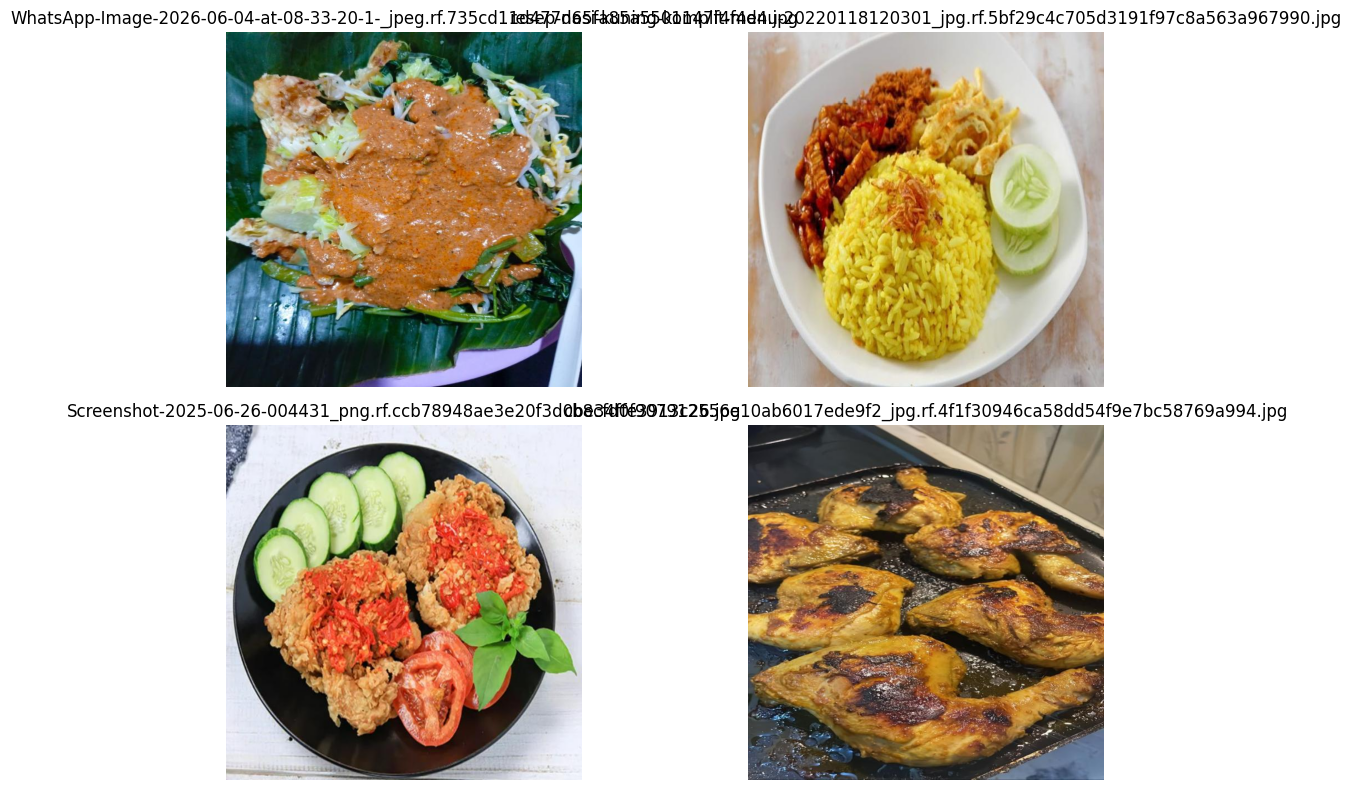

In [ ]:
# =========================================================
# 8. TAMPILKAN SAMPLE IMAGE
# =========================================================
image_dir = os.path.join(DATASET_PATH, 'train/images')

sample_images = random.sample(os.listdir(image_dir), 4)

plt.figure(figsize=(12,8))

for i, img_name in enumerate(sample_images):

    img_path = os.path.join(image_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 9. HITUNG DISTRIBUSI ANOTASI PER CLASS (train)
# =========================================================
label_dir = os.path.join(DATASET_PATH, 'train/labels')

class_counts = {}

for label_file in os.listdir(label_dir):

    label_path = os.path.join(label_dir, label_file)

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:

        class_id = int(line.split()[0])

        if class_id not in class_counts:
            class_counts[class_id] = 0

        class_counts[class_id] += 1

class_names = data_yaml['names']

results = []

for class_id, count in class_counts.items():
    results.append([class_names[class_id], count])

df = pd.DataFrame(results, columns=['Class', 'Annotations'])

df = df.sort_values(by='Annotations', ascending=False)

print(df)

           Class  Annotations
1     Nasi Putih           89
17   Telur Rebus           85
4   Tempe Goreng           59
12         Bakso           51
2    Lele Goreng           50
13    Mie Goreng           49
9    Ayam Geprek           47
14    Ayam Bakar           44
6        Rendang           42
0          Pecel           41
11  Telur Goreng           41
3    Tahu Goreng           41
7    Ayam Goreng           40
8      Soto Ayam           39
5      Sate Ayam           38
15    Sayur Asem           37
16   Nasi Kuning           37
10   Nasi Goreng           32


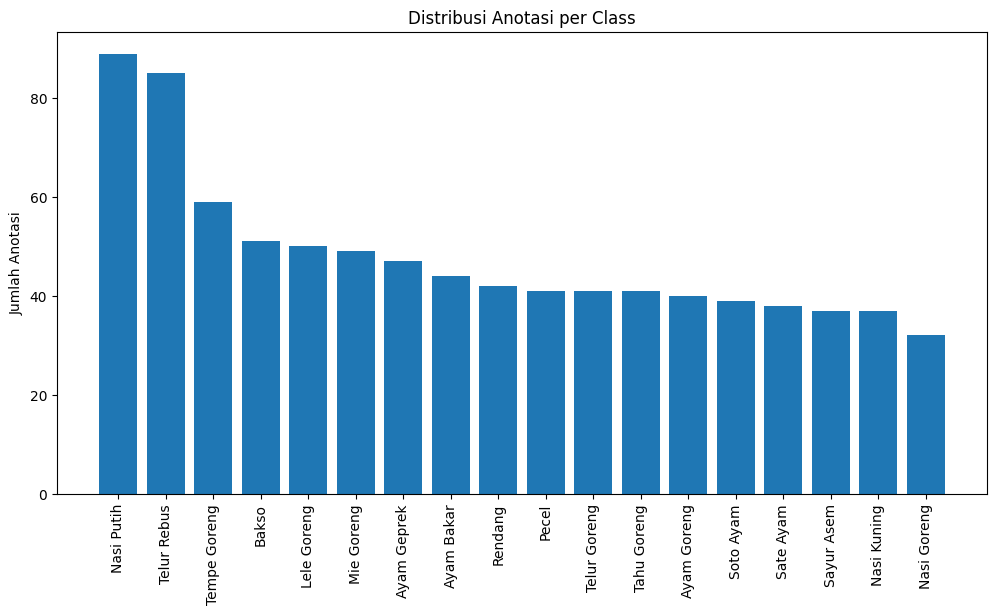

In [ ]:
# =========================================================
# 10. VISUALISASI DISTRIBUSI CLASS
# =========================================================
plt.figure(figsize=(12,6))

plt.bar(df['Class'], df['Annotations'])

plt.xticks(rotation=90)
plt.ylabel("Jumlah Anotasi")
plt.title("Distribusi Anotasi per Class")

plt.show()

In [ ]:

# =========================================================
# 11. CEK JUMLAH DISTRIBUSI DATA
# =========================================================
from collections import defaultdict

counts = defaultdict(lambda: {"train":0, "valid":0, "test":0})

for split in ["train", "valid", "test"]:
    label_dir = Path(DATASET_PATH) / split / "labels"
    for txt in label_dir.glob("*.txt"):
        with open(txt) as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    name = model.names[cls]
                    counts[name][split] += 1

df_dist = pd.DataFrame(counts).T.fillna(0).astype(int)
df_dist["Total"] = df_dist.sum(axis=1)
df_dist = df_dist.sort_index()
print(df_dist.to_string())

              train  valid  test  Total
Ayam Bakar       44     15     6     65
Ayam Geprek      47     13     4     64
Ayam Goreng      40     16     9     65
Bakso            51     12     5     68
Lele Goreng      50     13     7     70
Mie Goreng       49     14     6     69
Nasi Goreng      32     14     7     53
Nasi Kuning      37     12     5     54
Nasi Putih       89     24    14    127
Pecel            41      9     5     55
Rendang          42     12     3     57
Sate Ayam        38     10     8     56
Sayur Asem       37     12     7     56
Soto Ayam        39     11     5     55
Tahu Goreng      41     22     7     70
Telur Goreng     41     11     6     58
Telur Rebus      85     16    10    111
Tempe Goreng     59     15    12     86


In [5]:
# =========================================================
# 12. ANALISIS BRIGHTNESS & CONTRAST
# =========================================================
import numpy as np

image_dir = os.path.join(DATASET_PATH, 'train/images')
image_files = os.listdir(image_dir)

brightness_list = []
contrast_list = []

for img_name in image_files:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)      # rata-rata intensitas piksel
    contrast = np.std(gray)         # standar deviasi intensitas piksel

    brightness_list.append(brightness)
    contrast_list.append(contrast)

brightness_arr = np.array(brightness_list)
contrast_arr = np.array(contrast_list)

print(f"Jumlah gambar dianalisis: {len(brightness_arr)}")
print(f"Brightness - mean: {brightness_arr.mean():.2f}, std: {brightness_arr.std():.2f}, min: {brightness_arr.min():.2f}, max: {brightness_arr.max():.2f}")
print(f"Contrast   - mean: {contrast_arr.mean():.2f}, std: {contrast_arr.std():.2f}, min: {contrast_arr.min():.2f}, max: {contrast_arr.max():.2f}")


Jumlah gambar dianalisis: 475
Brightness - mean: 131.17, std: 20.49, min: 66.61, max: 190.50
Contrast   - mean: 56.50, std: 9.81, min: 30.72, max: 90.19


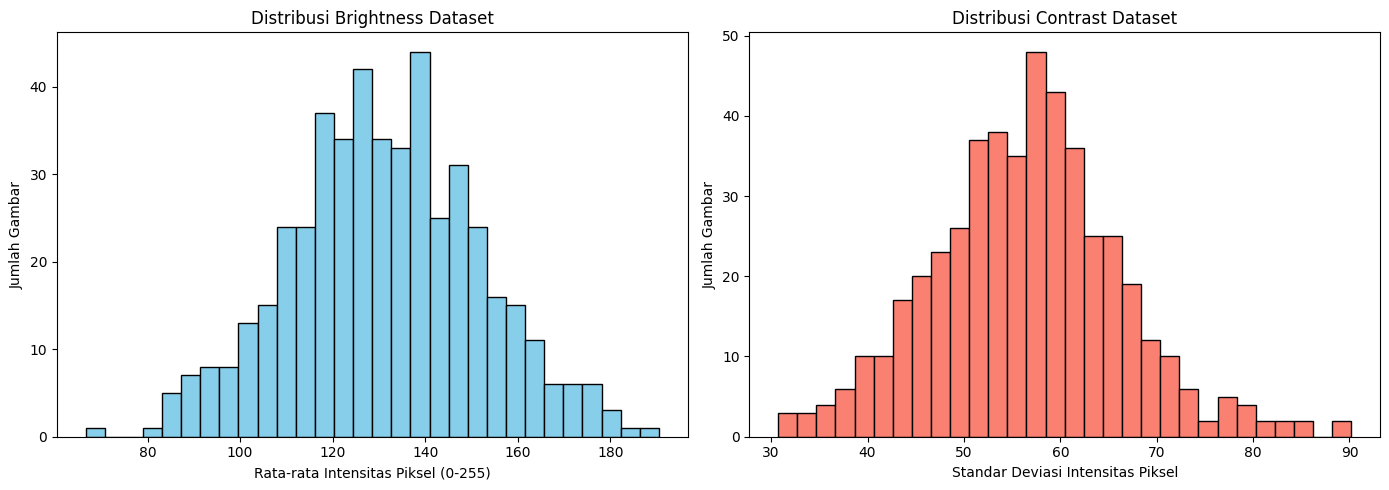

In [6]:
# =========================================================
# 13. VISUALISASI HISTOGRAM BRIGHTNESS & CONTRAST
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(brightness_arr, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribusi Brightness Dataset')
axes[0].set_xlabel('Rata-rata Intensitas Piksel (0-255)')
axes[0].set_ylabel('Jumlah Gambar')

axes[1].hist(contrast_arr, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Distribusi Contrast Dataset')
axes[1].set_xlabel('Standar Deviasi Intensitas Piksel')
axes[1].set_ylabel('Jumlah Gambar')

plt.tight_layout()
plt.savefig('brightness_contrast_distribution.png', dpi=150)
plt.show()

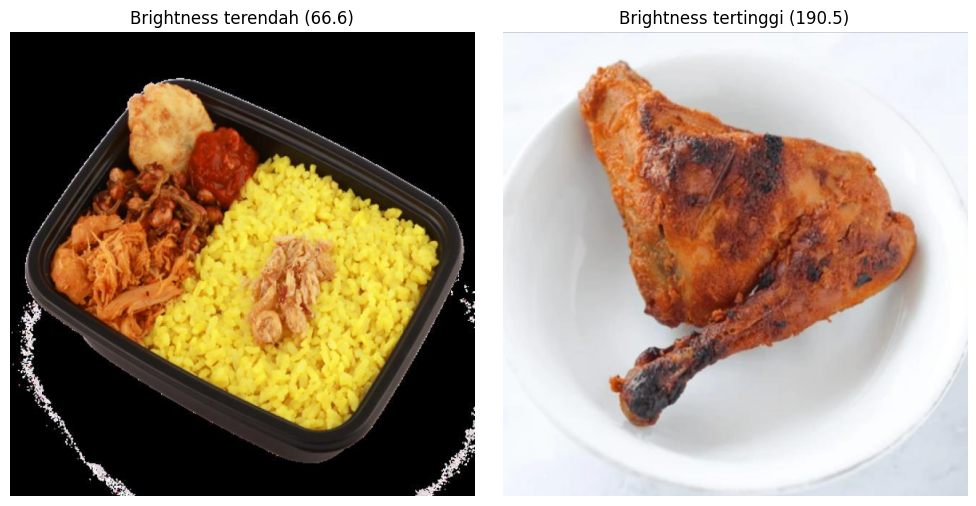

In [7]:
# =========================================================
# 14. CONTOH GAMBAR TERGELAP vs TERTERANG
# =========================================================
darkest_idx = np.argmin(brightness_arr)
brightest_idx = np.argmax(brightness_arr)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

img_dark = cv2.cvtColor(cv2.imread(os.path.join(image_dir, image_files[darkest_idx])), cv2.COLOR_BGR2RGB)
img_bright = cv2.cvtColor(cv2.imread(os.path.join(image_dir, image_files[brightest_idx])), cv2.COLOR_BGR2RGB)

axes[0].imshow(img_dark)
axes[0].set_title(f'Brightness terendah ({brightness_arr[darkest_idx]:.1f})')
axes[0].axis('off')

axes[1].imshow(img_bright)
axes[1].set_title(f'Brightness tertinggi ({brightness_arr[brightest_idx]:.1f})')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('brightness_examples.png', dpi=150)
plt.show()

In [ ]:
# =========================================================
# 15. LOAD MODEL YOLOv8
# =========================================================
model = YOLO('yolov8s.pt')

print("Model berhasil dimuat")

Model berhasil dimuat


In [ ]:
# =========================================================
# 16. TRAINING MODEL
# AUGMENTASI OTOMATIS YOLO (ON THE FLY)
# =========================================================

results = model.train(
    data= YAML_PATH,
    epochs=100,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    patience=20,
    augment=True,
    project='/content/drive/MyDrive/!Skripsi/Results',
    name='yolov8s_v2',
    exist_ok=False,
    verbose=True,
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/!Skripsi/Dataset/v2noAugment/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v2-2, nbs=64, nms=False, opset=None, optimize=False, optimize

In [ ]:


# =========================================================
# 17. EVALUASI PADA TEST
# =========================================================

# Load ulang model dari weights yang sudah tersimpan
WEIGHTS_PATH = '/content/drive/MyDrive/!Skripsi/Results/yolov8s_v2/weights/best.pt'

model = YOLO(WEIGHTS_PATH)

# Evaluasi test set
metrics = model.val(data=YAML_PATH, split='test')

print(metrics.box.map)    # mAP@0.5:0.95
print(metrics.box.map50)  # mAP@0.5
print(metrics.box.mp)     # mean Precision
print(metrics.box.mr)     # mean Recall

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,132,550 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 1.3±0.8 ms, read: 14.2±4.6 MB/s, size: 55.4 KB)
val: Scanning /content/drive/MyDrive/!Skripsi/Dataset/v2noAugment/test/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 15.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.5s
                   all         68        126       0.77      0.827      0.851      0.629
            Ayam Bakar          4          6      0.774       0.58      0.827      0.537
           Ayam Geprek          3          4      0.604        0.5      0.495      0.445
           Ayam Goreng          4          9      0.438      0.348      0.335      0.249
                 Bakso          5          5      0.763          1      0.962      0.858
           Lele Goreng

In [ ]:
# ============================================================
#  EVALUASI YOLOv8 — FIXED VERSION
# ============================================================

from ultralytics import YOLO
import torch, yaml, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─── KONFIGURASI — sesuaikan path ini ───
DRIVE_BASE   = "/content/drive/MyDrive/!Skripsi"
DATA_YAML    = f"{DRIVE_BASE}/Dataset/v2noAugment/data.yaml"
WEIGHTS_PATH = f"{DRIVE_BASE}/Results/yolov8s_v2/weights/best.pt"   # ← v1 → v2
RESULTS_DIR  = f"{DRIVE_BASE}/Results/yolov8s_v2"                   # ← v1 → v2
SAVE_DIR     = f"{DRIVE_BASE}/Evaluasi/yolov8s_v2"                  # ← tambah subfolder
model = YOLO(WEIGHTS_PATH)
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# ════════════════════════════════════════════
#  1. INFORMASI MODEL
# ════════════════════════════════════════════
print("\n" + "="*55)
print("  1. INFORMASI MODEL")
print("="*55)

# model.info() di ultralytics terbaru return None, pakai cara alternatif
model_info = model.model  # akses PyTorch model langsung

params      = sum(p.numel() for p in model_info.parameters())
gradients   = sum(p.numel() for p in model_info.parameters() if p.requires_grad)
layers      = len(list(model_info.modules()))
weight_size_mb = Path(WEIGHTS_PATH).stat().st_size / (1024**2)

# GFLOPs — hitung via thop jika tersedia, fallback manual
try:
    from thop import profile
    dummy_input = torch.zeros(1, 3, 640, 640).to(next(model_info.parameters()).device)
    macs, _ = profile(model_info, inputs=(dummy_input,), verbose=False)
    gflops = macs * 2 / 1e9
except Exception:
    # fallback: baca dari model.yaml jika ada, atau tampilkan N/A
    gflops = getattr(model, 'flops', None)
    if gflops is None:
        gflops = float('nan')

print(f"  Jumlah layer     : {layers}")
print(f"  Jumlah parameter : {params:,}")
print(f"  GFLOPs           : {gflops:.1f}" if not (gflops != gflops) else "  GFLOPs           : N/A (install thop)")
print(f"  Ukuran best.pt   : {weight_size_mb:.2f} MB")
device_info = 'GPU - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f"  Device           : {device_info}")


  1. INFORMASI MODEL
  Jumlah layer     : 226
  Jumlah parameter : 11,142,566
  GFLOPs           : 28.7
  Ukuran best.pt   : 21.49 MB
  Device           : GPU - Tesla T4


In [ ]:
# ════════════════════════════════════════════
#  2. BACA CLASS NAMES — FIX ERROR 1
#     yaml['names'] bisa berupa list ATAU dict {0:'cat', 1:'dog'}
#     keduanya ditangani di sini
# ════════════════════════════════════════════
with open(DATA_YAML) as f:
    yaml_data = yaml.safe_load(f)

names_raw = yaml_data["names"]

# Normalkan ke list terurut
if isinstance(names_raw, dict):
    class_names = [names_raw[k] for k in sorted(names_raw.keys())]
else:
    class_names = list(names_raw)   # sudah list, tidak perlu .values()

print(f"\n  Kelas terdeteksi ({len(class_names)}): {class_names}")


  Kelas terdeteksi (18): ['Ayam Bakar', 'Ayam Geprek', 'Ayam Goreng', 'Bakso', 'Lele Goreng', 'Mie Goreng', 'Nasi Goreng', 'Nasi Kuning', 'Nasi Putih', 'Pecel', 'Rendang', 'Sate Ayam', 'Sayur Asem', 'Soto Ayam', 'Tahu Goreng', 'Telur Goreng', 'Telur Rebus', 'Tempe Goreng']


In [ ]:
# ════════════════════════════════════════════
#  3. EVALUASI METRIK
# ════════════════════════════════════════════
print("\n" + "="*55)
print("  3. METRIK EVALUASI")
print("="*55)

metrics_val  = model.val(data=DATA_YAML, split='val',  verbose=False)
metrics_test = model.val(data=DATA_YAML, split='test', verbose=False)

def get_metrics(m):
    p  = float(m.box.mp)
    r  = float(m.box.mr)
    f1 = 2 * p * r / (p + r + 1e-9)
    return {"Precision": p, "Recall": r, "F1": f1,
            "mAP@0.5": float(m.box.map50),
            "mAP@0.5:0.95": float(m.box.map)}

mv = get_metrics(metrics_val)
mt = get_metrics(metrics_test)

df_summary = pd.DataFrame([mv, mt], index=["Validation", "Test"]).round(4)
print(f"\n{df_summary.to_string()}")


# ── Per-kelas (test set) — FIX ERROR 3 ──
# ap50/ap dari ultralytics hanya berisi kelas yang MUNCUL di test set.
# Jika ada kelas tanpa sampel di test set, panjangnya bisa < len(class_names).
# Kita cocokkan lewat names yang dikembalikan metrics itu sendiri.

print(f"\n  ── Per Kelas (Test Set) ──")


# Ambil mapping nama kelas dari metrics (hanya yang ada di test set)
# AP hanya untuk kelas yang muncul di test set
ap50 = np.array(metrics_test.box.ap50)
ap95 = np.array(metrics_test.box.ap)

# indeks kelas yang sesuai dengan ap50/ap95
idxs = metrics_test.box.ap_class_index

# mapping indeks -> nama kelas yang benar
df_class = pd.DataFrame({
    "Class": [model.names[i] for i in idxs],
    "AP@0.5": np.round(ap50, 4),
    "AP@0.5:0.95": np.round(ap95, 4),
})

# Tandai kelas yang tidak ada di test set
all_classes = list(model.names.values())

missing = [c for c in all_classes if c not in df_class["Class"].values]
if missing:
    print(f"\n  ⚠ Class TIDAK ADA di test set (AP=0): {missing}")
    for m in missing:
        df_class = pd.concat([df_class,
            pd.DataFrame([{"Class": m, "AP@0.5": 0.0, "AP@0.5:0.95": 0.0}])],
            ignore_index=True)

df_class = df_class.sort_values("Class").reset_index(drop=True)
print(f"\n{df_class.to_string(index=False)}")
df_class.to_csv(f"{SAVE_DIR}/metrik_per_kelas.csv", index=False)
print(f"\n  ✔ Disimpan: {SAVE_DIR}/metrik_per_kelas.csv")



  3. METRIK EVALUASI
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 1.3±1.3 ms, read: 0.9±1.6 MB/s, size: 61.7 KB)
val: Scanning /content/drive/MyDrive/!Skripsi/Dataset/v2noAugment/valid/labels.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 27.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.2it/s 7.4s
                   all        139        251       0.85       0.89      0.925      0.677
Speed: 7.3ms preprocess, 11.3ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 0.1±0.0 MB/s, size: 56.9 KB)
val: Scanning /content/drive/MyDrive/!Skripsi/Dataset/v2noAugment/test/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 

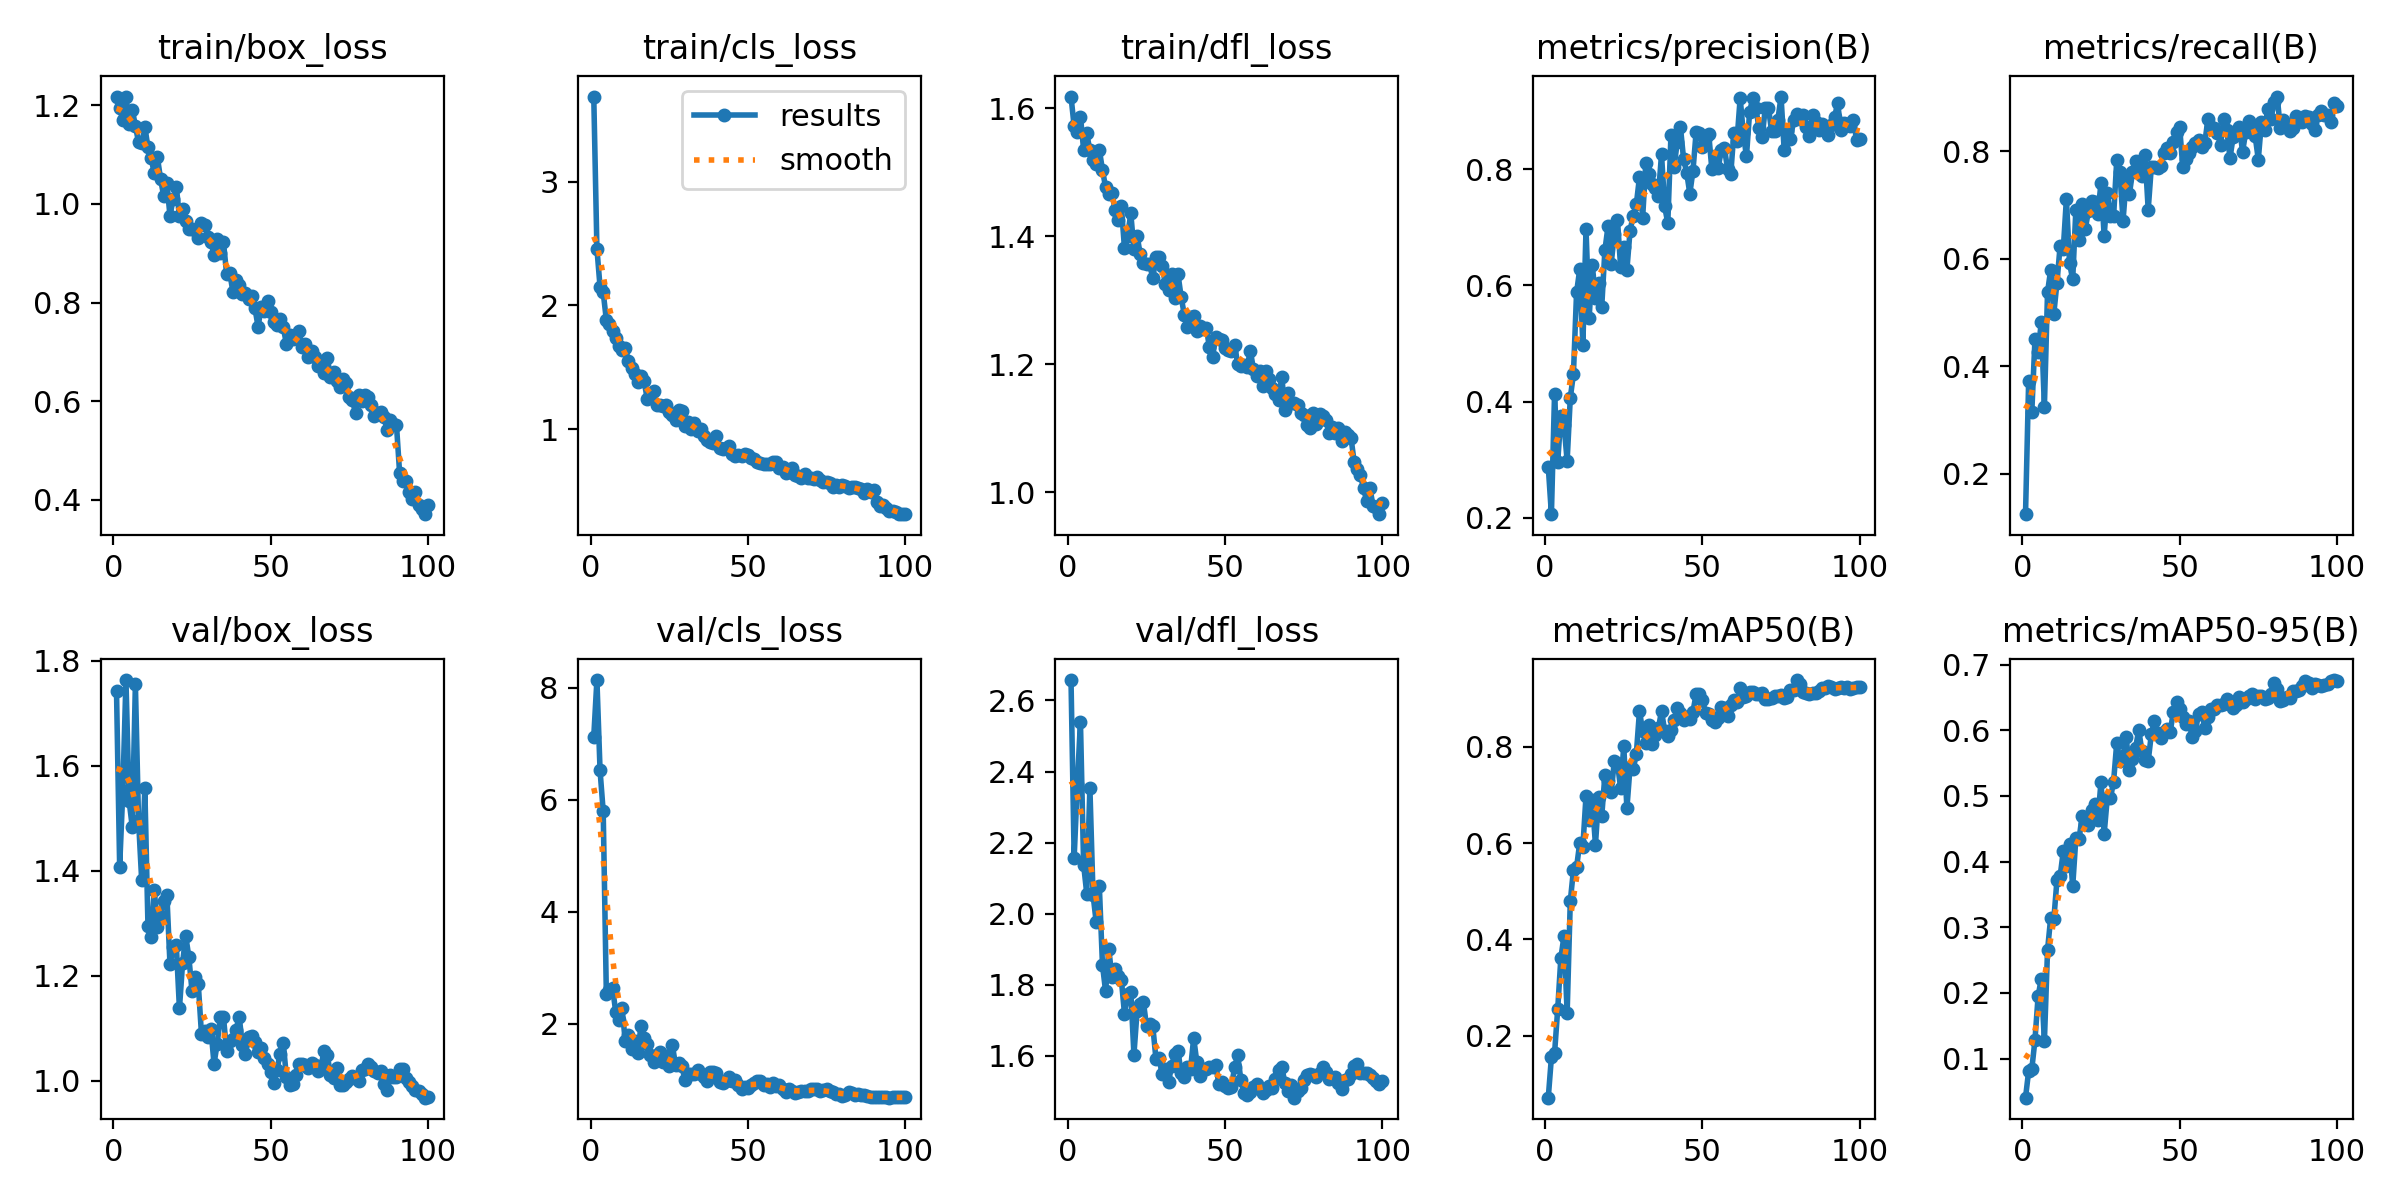

In [ ]:
from IPython.display import Image

Image(
    filename='/content/drive/MyDrive/!Skripsi/Results/yolov8s_v2/results.png',
    width=1200
)

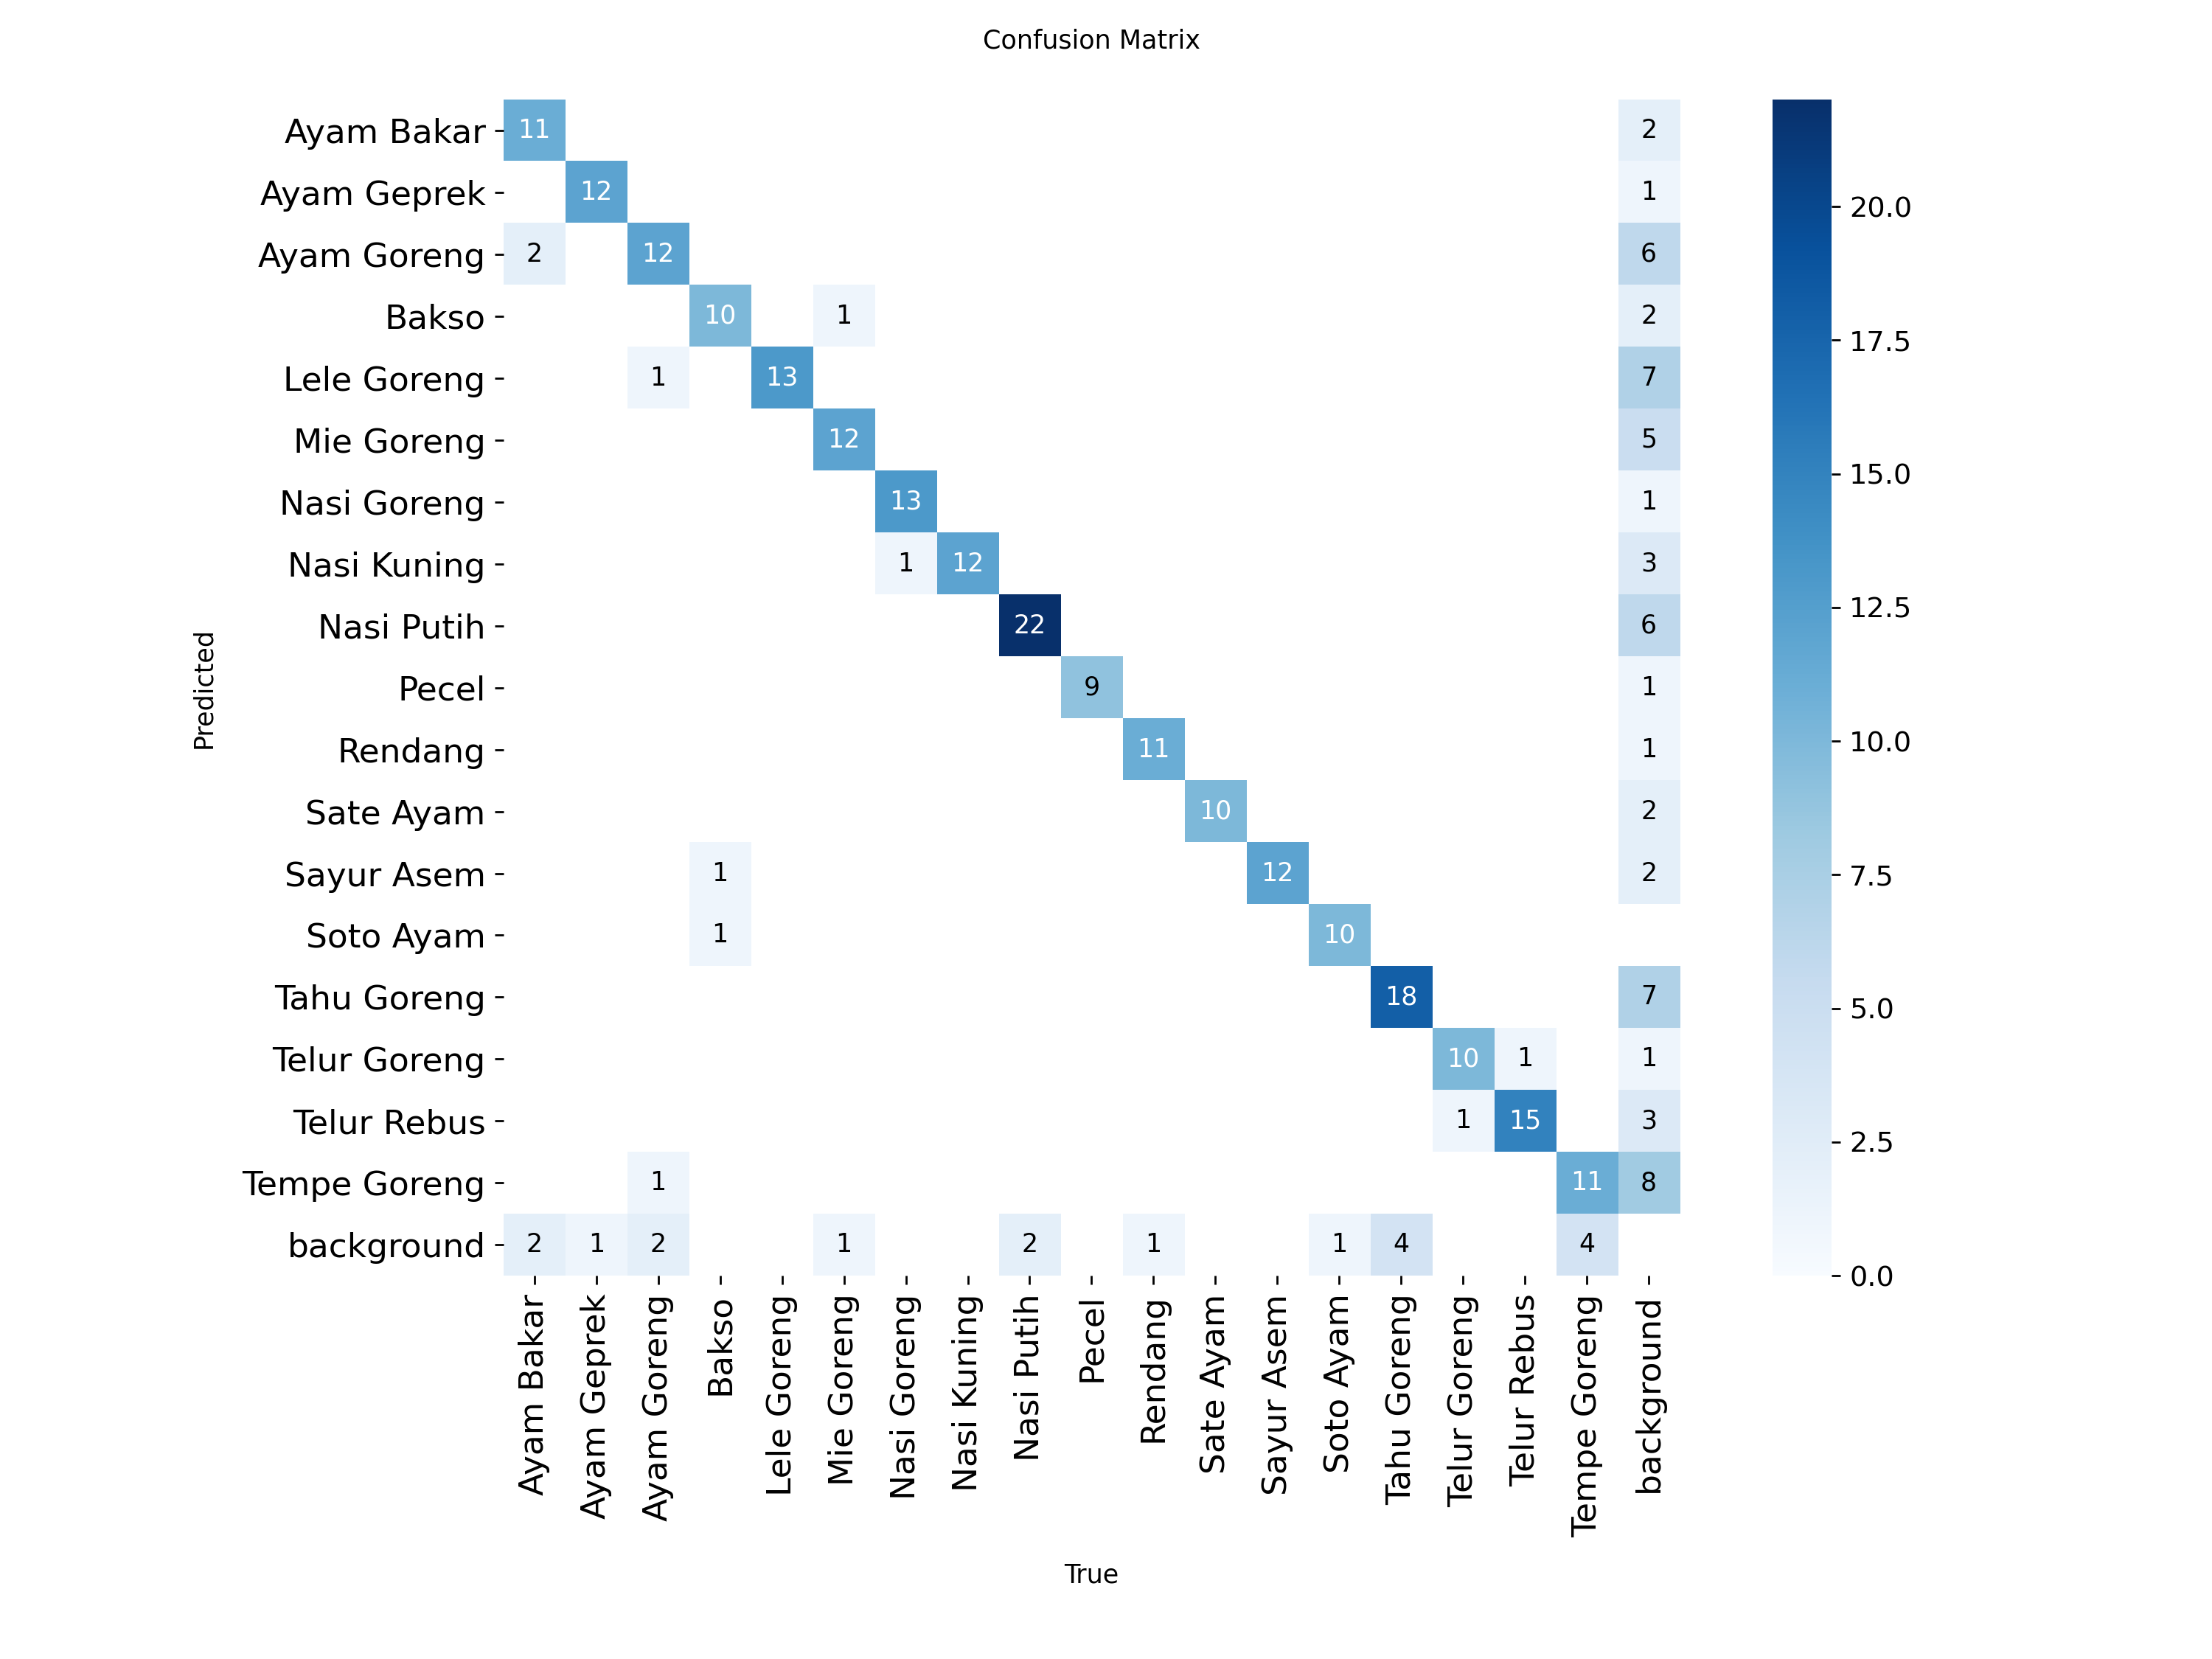

In [ ]:
Image(
    filename='/content/drive/MyDrive/!Skripsi/Results/yolov8s_v2/confusion_matrix.png',
    width=1200
)

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/!Skripsi/Results/yolov8s_v2/results.csv')

df.head()
#print(df.columns)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,16.2211,1.21681,3.68958,1.61845,0.28793,0.12474,0.07104,0.04034,1.74156,7.12938,2.65735,0.000290,0.000290,0.071290
1,2,31.3620,1.19408,2.45956,1.57170,0.20624,0.37277,0.15472,0.08103,1.40780,8.13993,2.15765,0.000584,0.000584,0.041584
2,3,44.2593,1.17097,2.14948,1.56245,0.41359,0.31462,0.16325,0.08384,1.55128,6.52513,2.36356,0.000872,0.000872,0.011872
3,4,61.3223,1.21792,2.10565,1.58716,0.29592,0.44966,0.25482,0.12811,1.76309,5.79407,2.53980,0.000970,0.000970,0.000970
4,5,80.5919,1.16244,1.88209,1.53570,0.37467,0.42554,0.36098,0.19461,1.53311,2.52980,2.13827,0.000960,0.000960,0.000960


In [ ]:
last_row = df.iloc[-1]

print(last_row[['metrics/precision(B)',
                'metrics/recall(B)',
                'metrics/mAP50(B)',
                'metrics/mAP50-95(B)']])

metrics/precision(B)    0.85235
metrics/recall(B)       0.88451
metrics/mAP50(B)        0.92474
metrics/mAP50-95(B)     0.67472
Name: 99, dtype: float64


In [ ]:
best_epoch = df.loc[df['metrics/mAP50(B)'].idxmax()]

print(best_epoch[['epoch',
                  'metrics/precision(B)',
                  'metrics/recall(B)',
                  'metrics/mAP50(B)',
                  'metrics/mAP50-95(B)']])

epoch                   80.00000
metrics/precision(B)     0.89554
metrics/recall(B)        0.89167
metrics/mAP50(B)         0.93864
metrics/mAP50-95(B)      0.67142
Name: 79, dtype: float64


In [ ]:
from ultralytics import YOLO

model = YOLO(WEIGHTS_PATH)

model.info()

Model summary: 130 layers, 11,142,566 parameters, 0 gradients, 28.7 GFLOPs


(130, 11142566, 0, 28.68352)

In [ ]:
import os

size_mb = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)

print(f"Size: {size_mb:.2f} MB")

Size: 21.49 MB



  4. GRAFIK TRAINING (Loss & Metrik per Epoch)

  Kolom tersedia di results.csv:
  ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']



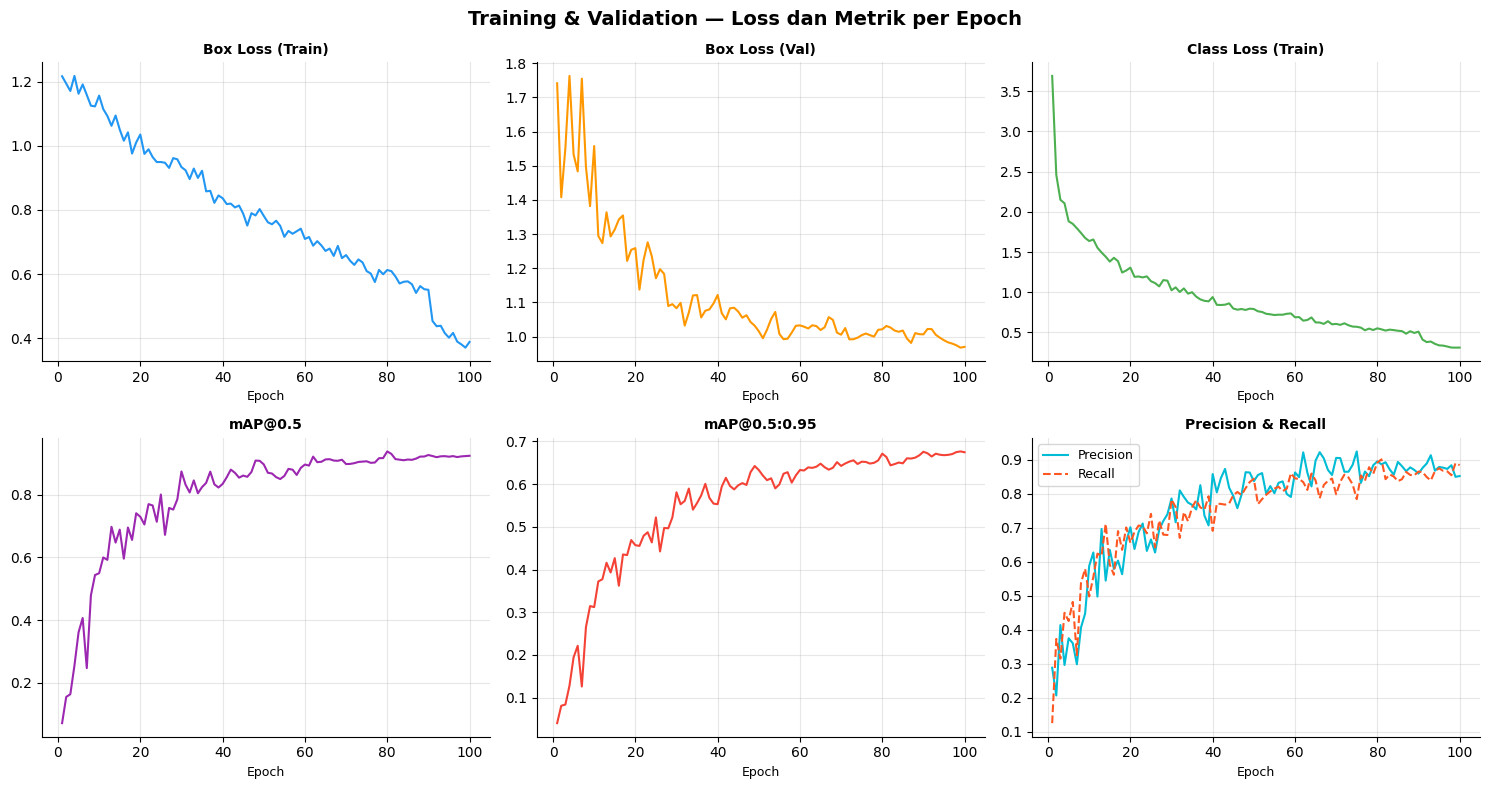

  ✔ Disimpan: /content/drive/MyDrive/!Skripsi/Evaluasi/yolov8s_v2/grafik_training.png


In [ ]:
# ════════════════════════════════════════════
#  4. GRAFIK TRAINING — FIX ERROR 2
#     Cek nama kolom results.csv dulu sebelum plot
# ════════════════════════════════════════════
print("\n" + "="*55)
print("  4. GRAFIK TRAINING (Loss & Metrik per Epoch)")
print("="*55)

csv_path = Path(RESULTS_DIR) / "results.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Tampilkan kolom yang tersedia untuk debugging
    print(f"\n  Kolom tersedia di results.csv:\n  {list(df.columns)}\n")

    epochs = df["epoch"]

    # ── Deteksi nama kolom secara dinamis ──
    def find_col(df, *candidates):
        """Kembalikan nama kolom pertama yang ditemukan, atau None."""
        for c in candidates:
            if c in df.columns:
                return c
        return None

    COL_BOX_TRAIN = find_col(df, "train/box_loss")
    COL_BOX_VAL   = find_col(df, "val/box_loss")
    COL_CLS_TRAIN = find_col(df, "train/cls_loss")
    COL_MAP50     = find_col(df, "metrics/mAP50(B)",    "metrics/mAP50",    "metrics/mAP_0.5")
    COL_MAP95     = find_col(df, "metrics/mAP50-95(B)", "metrics/mAP50-95", "metrics/mAP_0.5_0.95")
    COL_PREC      = find_col(df, "metrics/precision(B)", "metrics/precision", "metrics/P")
    COL_RECALL    = find_col(df, "metrics/recall(B)",    "metrics/recall",    "metrics/R")

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Training & Validation — Loss dan Metrik per Epoch",
                 fontsize=14, fontweight="bold")

    def safe_plot(ax, col, label, color, linestyle="-"):
        if col and col in df.columns:
            ax.plot(epochs, df[col], color=color, linewidth=1.5,
                    linestyle=linestyle, label=label)
        else:
            ax.text(0.5, 0.5, f"Kolom\n'{col}'\ntidak ada",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=9, color="gray")

    # Baris atas: loss
    safe_plot(axes[0,0], COL_BOX_TRAIN, "Box Loss Train", "#2196F3")
    axes[0,0].set_title("Box Loss (Train)", fontsize=10, fontweight="bold")

    safe_plot(axes[0,1], COL_BOX_VAL,   "Box Loss Val",   "#FF9800")
    axes[0,1].set_title("Box Loss (Val)", fontsize=10, fontweight="bold")

    safe_plot(axes[0,2], COL_CLS_TRAIN, "Cls Loss Train", "#4CAF50")
    axes[0,2].set_title("Class Loss (Train)", fontsize=10, fontweight="bold")

    # Baris bawah: metrik
    safe_plot(axes[1,0], COL_MAP50, "mAP@0.5",      "#9C27B0")
    axes[1,0].set_title("mAP@0.5", fontsize=10, fontweight="bold")

    safe_plot(axes[1,1], COL_MAP95, "mAP@0.5:0.95", "#F44336")
    axes[1,1].set_title("mAP@0.5:0.95", fontsize=10, fontweight="bold")

    # Precision & Recall — hanya plot kalau kolomnya ada
    if COL_PREC and COL_RECALL:
        safe_plot(axes[1,2], COL_PREC,   "Precision", "#00BCD4")
        safe_plot(axes[1,2], COL_RECALL, "Recall",    "#FF5722", linestyle="--")
        axes[1,2].legend(fontsize=9)
    else:
        axes[1,2].text(0.5, 0.5, "Kolom Precision/Recall\ntidak ditemukan",
                       ha="center", va="center", transform=axes[1,2].transAxes,
                       fontsize=9, color="gray")
    axes[1,2].set_title("Precision & Recall", fontsize=10, fontweight="bold")

    for ax in axes.flat:
        ax.set_xlabel("Epoch", fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    out = f"{SAVE_DIR}/grafik_training.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✔ Disimpan: {out}")

else:
    print("  ⚠ results.csv tidak ditemukan.")




  5. GRAFIK AP PER KELAS


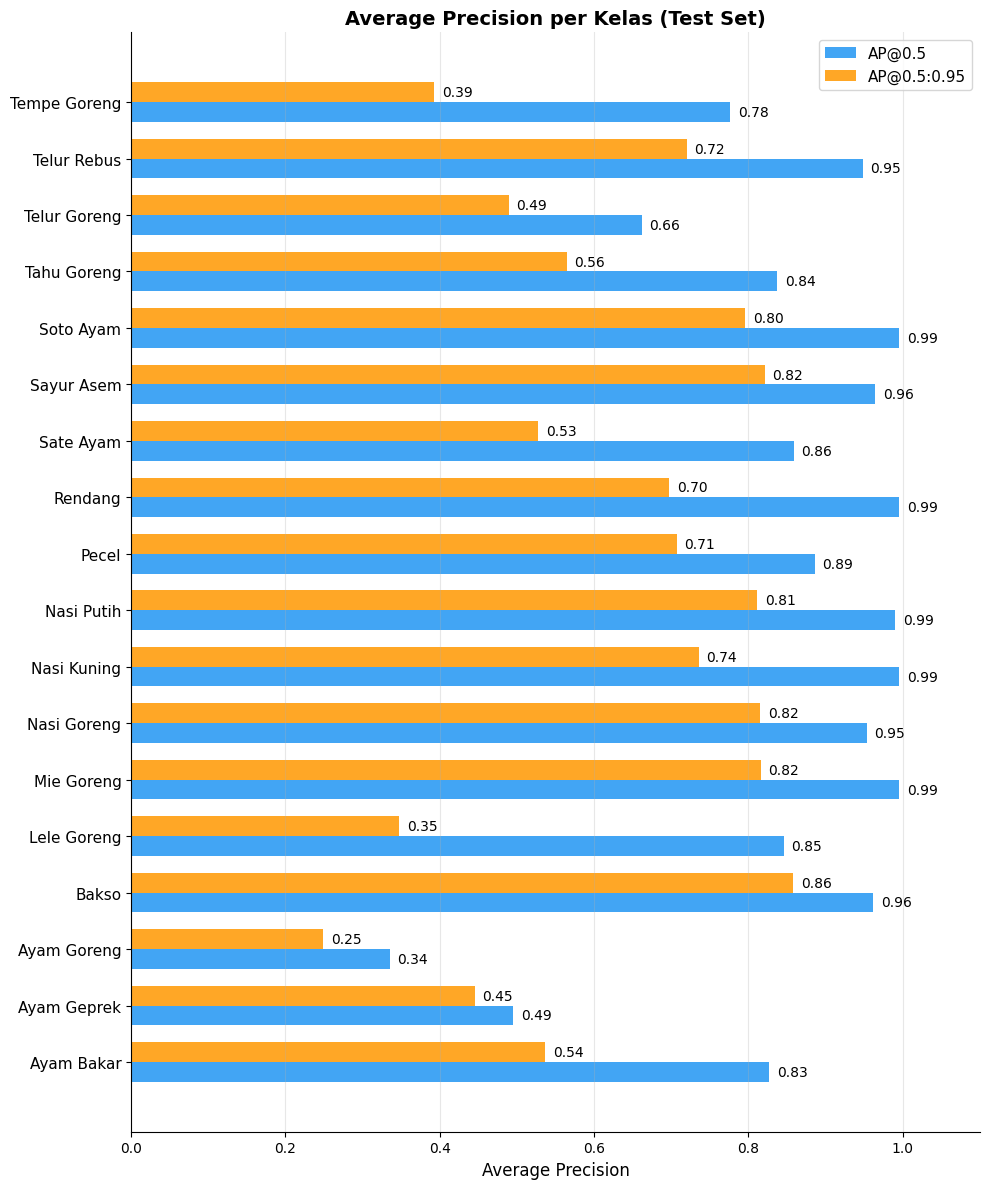

✔ Disimpan: /content/drive/MyDrive/!Skripsi/Evaluasi/yolov8s_v2/ap_per_kelas_horizontal.png


In [7]:
# ════════════════════════════════════════════
#     BAR CHART AP PER KELAS — FIX ERROR 3
#     Menggunakan df_class yang sudah bersih di atas
# ════════════════════════════════════════════
import pandas as pd

DRIVE_BASE   = "/content/drive/MyDrive/!Skripsi"
SAVE_DIR     = f"{DRIVE_BASE}/Evaluasi/yolov8s_v2"
df_class = pd.read_csv(f"{SAVE_DIR}/metrik_per_kelas.csv")

print("\n" + "="*55)
print("  5. GRAFIK AP PER KELAS")
print("="*55)

n = len(df_class)

# ukuran portrait
fig, ax = plt.subplots(figsize=(10, 12))

y = np.arange(n)
h = 0.35

bars1 = ax.barh(
    y - h/2,
    df_class["AP@0.5"],
    height=h,
    label="AP@0.5",
    color="#2196F3",
    alpha=0.85
)

bars2 = ax.barh(
    y + h/2,
    df_class["AP@0.5:0.95"],
    height=h,
    label="AP@0.5:0.95",
    color="#FF9800",
    alpha=0.85
)

# menampilkan nilai di ujung bar
for bar in list(bars1) + list(bars2):
    w = bar.get_width()
    ax.text(
        w + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{w:.2f}",
        va="center",
        fontsize=10
    )

ax.set_yticks(y)
ax.set_yticklabels(df_class["Class"], fontsize=11)

ax.set_xlabel("Average Precision", fontsize=12)
ax.set_title(
    "Average Precision per Kelas (Test Set)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlim(0, 1.1)

ax.legend(fontsize=11)

ax.grid(axis="x", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

out = f"{SAVE_DIR}/ap_per_kelas_horizontal.png"
plt.savefig(out, dpi=600, bbox_inches="tight")

plt.show()

print(f"✔ Disimpan: {out}")


  5. GRAFIK AP PER KELAS


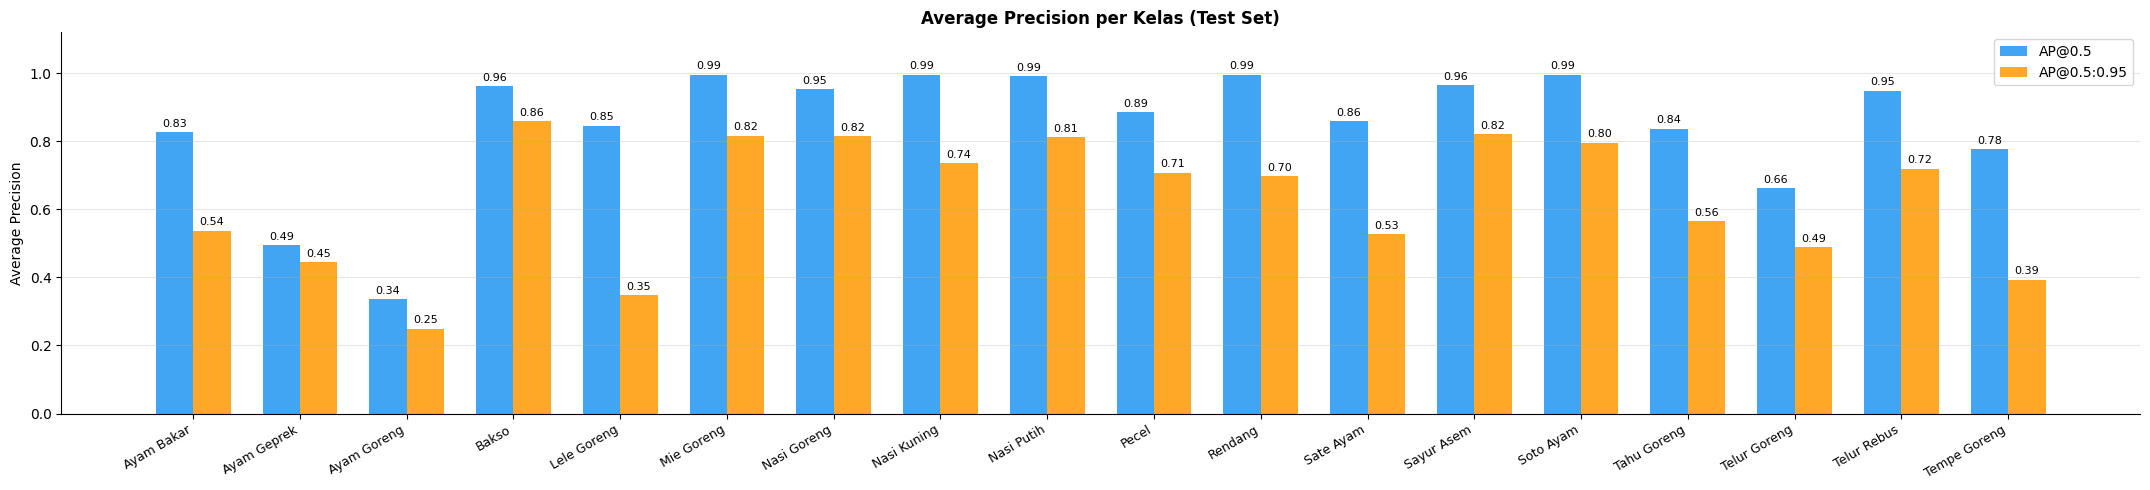

  ✔ Disimpan: /content/drive/MyDrive/!Skripsi/Evaluasi/yolov8s_v2/ap_per_kelas.png


In [ ]:
# ════════════════════════════════════════════
#  5. BAR CHART AP PER KELAS — FIX ERROR 3
#     Menggunakan df_class yang sudah bersih di atas
# ════════════════════════════════════════════
print("\n" + "="*55)
print("  5. GRAFIK AP PER KELAS")
print("="*55)

n = len(df_class)
fig, ax = plt.subplots(figsize=(max(8, n * 1.2), 5))
x = np.arange(n)
w = 0.35

bars1 = ax.bar(x - w/2, df_class["AP@0.5"],      width=w,
               label="AP@0.5",      color="#2196F3", alpha=0.85)
bars2 = ax.bar(x + w/2, df_class["AP@0.5:0.95"], width=w,
               label="AP@0.5:0.95", color="#FF9800", alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_class["Kelas"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Average Precision", fontsize=10)
ax.set_title("Average Precision per Kelas (Test Set)", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
out = f"{SAVE_DIR}/ap_per_kelas.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✔ Disimpan: {out}")





  6. RADAR CHART — RINGKASAN METRIK


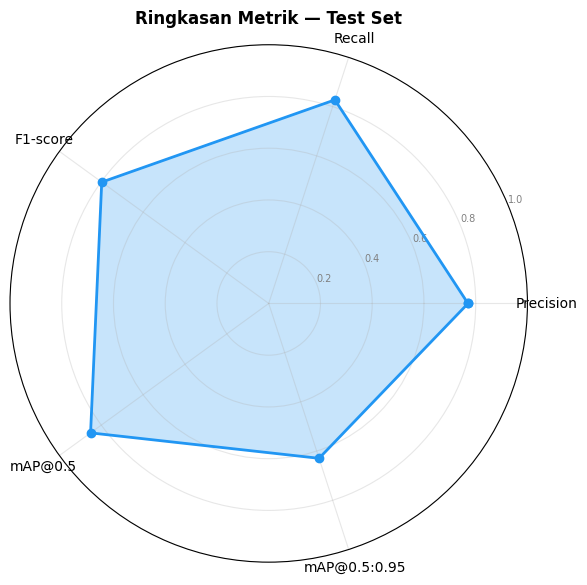

  ✔ Disimpan: /content/drive/MyDrive/!Skripsi/Evaluasi/yolov8s_v2/radar_metrik.png


In [ ]:

# ════════════════════════════════════════════
#  6. RADAR CHART
# ════════════════════════════════════════════
print("\n" + "="*55)
print("  6. RADAR CHART — RINGKASAN METRIK")
print("="*55)

labels_r = ["Precision", "Recall", "F1-score", "mAP@0.5", "mAP@0.5:0.95"]
vals_r   = [mt["Precision"], mt["Recall"], mt["F1"],
            mt["mAP@0.5"], mt["mAP@0.5:0.95"]]
N        = len(labels_r)
angles   = [n / float(N) * 2 * np.pi for n in range(N)] + \
           [0 / float(N) * 2 * np.pi]  # tutup lingkaran
vals_r  += vals_r[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, vals_r, "o-", linewidth=2, color="#2196F3")
ax.fill(angles, vals_r, alpha=0.25, color="#2196F3")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=7, color="gray")
ax.set_title("Ringkasan Metrik — Test Set", fontsize=12, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = f"{SAVE_DIR}/radar_metrik.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✔ Disimpan: {out}")


In [ ]:
# ════════════════════════════════════════════
#  7. KECEPATAN INFERENSI
# ════════════════════════════════════════════
import torch
import time
import numpy as np

print("\n" + "="*55)
print("  7. KECEPATAN INFERENSI")
print("="*55)

device = "cuda" if torch.cuda.is_available() else "cpu"
dummy  = torch.zeros(1, 3, 640, 640)
times  = []

for _ in range(20):
    t0 = time.perf_counter()
    model.predict(source=dummy, verbose=False, device=device)
    times.append((time.perf_counter() - t0) * 1000)

times   = times[5:]
mean_ms = np.mean(times)
fps     = 1000 / mean_ms

print(f"  Rata-rata inferensi : {mean_ms:.2f} ms/gambar")
print(f"  Throughput          : {fps:.1f} FPS")


  7. KECEPATAN INFERENSI
  Rata-rata inferensi : 18.15 ms/gambar
  Throughput          : 55.1 FPS


In [ ]:
# ════════════════════════════════════════════
#  8. TABEL RINGKASAN UNTUK SKRIPSI
# ════════════════════════════════════════════
from ultralytics import YOLO
import torch, time, os
import numpy as np
import pandas as pd
from pathlib import Path

# ── Load ulang semua yang diperlukan ──
WEIGHTS_PATH = "/content/drive/MyDrive/!Skripsi/Results/yolov8s_v2/weights/best.pt"
RESULTS_DIR  = "/content/drive/MyDrive/!Skripsi/Results/yolov8s_v2"
SAVE_DIR     = "/content/drive/MyDrive/!Skripsi/Evaluasi/yolov8s_v2"
DATA_YAML    = "/content/drive/MyDrive/!Skripsi/Dataset/v2noAugment/data.yaml"
os.makedirs(SAVE_DIR, exist_ok=True)

model = YOLO(WEIGHTS_PATH)

# Info model
model_info     = model.model
params         = sum(p.numel() for p in model_info.parameters())
weight_size_mb = Path(WEIGHTS_PATH).stat().st_size / (1024**2)
try:
    from thop import profile
    dummy_input = torch.zeros(1, 3, 640, 640).to(next(model_info.parameters()).device)
    macs, _    = profile(model_info, inputs=(dummy_input,), verbose=False)
    gflops     = macs * 2 / 1e9
except Exception:
    gflops = float('nan')

# Metrik test
metrics_test = model.val(data=DATA_YAML, split='test', verbose=False)
p  = float(metrics_test.box.mp)
r  = float(metrics_test.box.mr)
f1 = 2 * p * r / (p + r + 1e-9)
mt = {"Precision": p, "Recall": r, "F1": f1,
      "mAP@0.5": float(metrics_test.box.map50),
      "mAP@0.5:0.95": float(metrics_test.box.map)}

# Kecepatan inferensi
device = "cuda" if torch.cuda.is_available() else "cpu"
dummy  = torch.zeros(1, 3, 640, 640)
times  = []
for _ in range(20):
    t0 = time.perf_counter()
    model.predict(source=dummy, verbose=False, device=device)
    times.append((time.perf_counter() - t0) * 1000)
times   = times[5:]
mean_ms = np.mean(times)
fps     = 1000 / mean_ms

# Epoch dari results.csv
csv_path    = Path(RESULTS_DIR) / "results.csv"
df_csv      = pd.read_csv(csv_path) if csv_path.exists() else None
epoch_count = int(df_csv["epoch"].max()) if df_csv is not None else "N/A"

# ── Cetak tabel ──
print("\n" + "="*55)
print("  8. TABEL RINGKASAN UNTUK SKRIPSI")
print("="*55)

rows = [
    ("Model",               "YOLOv8s (pretrained COCO)"),
    ("Jumlah Parameter",    f"{params:,}"),
    ("GFLOPs",              f"{gflops:.1f}" if gflops == gflops else "N/A"),
    ("Ukuran Bobot (MB)",   f"{weight_size_mb:.2f}"),
    ("Epochs",              epoch_count),
    ("Precision (Test)",    f"{mt['Precision']:.4f}"),
    ("Recall (Test)",       f"{mt['Recall']:.4f}"),
    ("F1-score (Test)",     f"{mt['F1']:.4f}"),
    ("mAP@0.5 (Test)",      f"{mt['mAP@0.5']:.4f}"),
    ("mAP@0.5:0.95 (Test)", f"{mt['mAP@0.5:0.95']:.4f}"),
    ("Inferensi (ms/img)",  f"{mean_ms:.2f}"),
    ("FPS",                 f"{fps:.1f}"),
]

df_final = pd.DataFrame(rows, columns=["Metrik / Info", "Nilai"])
print(df_final.to_string(index=False))
df_final.to_csv(f"{SAVE_DIR}/ringkasan_evaluasi.csv", index=False)
print(f"\n  ✔ Disimpan: {SAVE_DIR}/ringkasan_evaluasi.csv")
print("="*55)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,132,550 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.4 ms, read: 34.5±11.5 MB/s, size: 60.1 KB)
val: Scanning /content/drive/MyDrive/!Skripsi/Dataset/v2noAugment/test/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 21.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.5s
                   all         68        126       0.77      0.827      0.851      0.629
Speed: 14.5ms preprocess, 9.9ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /content/runs/detect/val-3

  8. TABEL RINGKASAN UNTUK SKRIPSI
      Metrik / Info                     Nilai
              Model YOLOv8s (pretrained COCO)
   Jumlah Parameter                11,142,566
             GFLOPs                      28.7
  Ukuran Bobot (MB)           

In [ ]:
# ════════════════════════════════════════════
#  EXPORT BASELINE — PyTorch → ONNX → TFLite
# ════════════════════════════════════════════
!pip install -q onnxscript onnx

import torch

DRIVE_BASE   = "/content/drive/MyDrive/!Skripsi"
WEIGHTS_PATH = f"{DRIVE_BASE}/Results/yolov8s_v2/weights/best.pt"

# Folder output baseline — terpisah dari Pruning2, biar tidak campur
BASELINE_EXPORT_DIR = f"{DRIVE_BASE}/Results/yolov8s_v2/export"
ONNX_PATH = f"{BASELINE_EXPORT_DIR}/model_baseline.onnx"

import os
os.makedirs(BASELINE_EXPORT_DIR, exist_ok=True)

# Load model baseline
ckpt  = torch.load(WEIGHTS_PATH, map_location='cpu', weights_only=False)
model = ckpt['model'].float().cpu()
model.eval()

print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} params")

# Export ke ONNX — opset & flags SAMA PERSIS dengan export pruned
dummy = torch.zeros(1, 3, 640, 640)
torch.onnx.export(
    model,
    dummy,
    ONNX_PATH,
    opset_version   = 12,
    input_names     = ['images'],
    output_names    = ['output'],
    dynamic_axes    = {'images': {0: 'batch'}, 'output': {0: 'batch'}},
    verbose         = False,
)
print(f"✔ ONNX disimpan: {ONNX_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 6.9 MB/s eta 0:00:00
Model loaded: 11,142,566 params


/tmp/ipykernel_1152/722300828.py:27: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0630 12:26:43.507000 1152 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.model.22.anchors, self.model.22.strides were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API

✔ ONNX disimpan: /content/drive/MyDrive/!Skripsi/Results/yolov8s_v2/export/model_baseline.onnx


In [ ]:
# Convert ke TFLite (float32 saja — kita tidak butuh INT8 untuk baseline ini)
!pip install -q onnx2tf tensorflow sng4onnx onnx_graphsurgeon

TFLITE_OUTDIR = f"{BASELINE_EXPORT_DIR}/tflite_baseline"

!onnx2tf -i {ONNX_PATH} -o {TFLITE_OUTDIR} -oiqt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/32